# DATA PARTITIONING FOR FEDERATED LEARNING

In [ ]:
# ============================================
# CELL 1: Setup Environment
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/FL-Pneumonia-Detection'
os.chdir(PROJECT_ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import json
import shutil
from collections import defaultdict
from datetime import datetime
from pathlib import Path

print(f"✅ Working directory: {os.getcwd()}")



Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/FL-Pneumonia-Detection


In [ ]:
# ============================================
# CELL 2: Initialize WandB
# ============================================
wandb.login()

wandb.init(
    project="fl-pneumonia-detection",
    name="day4-data-partitioning",
    config={
        "phase": "partitioning",
        "week": 1,
        "day": 4,
        "num_hospitals": 3,
        "partition_strategies": ["iid", "non_iid"]
    }
)

print("✅ WandB initialized!")




/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: chiwa-vw (chiwa-vw-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✅ WandB initialized!


In [ ]:
# ============================================
# CELL 3: Define Paths
# ============================================
DATA_RAW = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_SPLITS = os.path.join(PROJECT_ROOT, 'data/splits')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
UTILS_DIR = os.path.join(PROJECT_ROOT, 'utils')

# Data location
CHEST_XRAY_DIR = os.path.join(DATA_RAW, 'chest_xray', 'chest_xray')

# Create splits directory
os.makedirs(DATA_SPLITS, exist_ok=True)

print(f"📂 Source data: {CHEST_XRAY_DIR}")
print(f"📂 Splits will be saved to: {DATA_SPLITS}")

📂 Source data: /content/drive/MyDrive/FL-Pneumonia-Detection/data/raw/chest_xray/chest_xray
📂 Splits will be saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/data/splits


In [ ]:
# ============================================
# CELL 4: Configuration
# ============================================
PARTITION_CONFIG = {
    "num_hospitals": 3,  # Start with 3, can increase to 5 later
    "strategies": ["iid", "non_iid"],
    "seed": 42,

    # Non-IID scenario (realistic hospital differences)
    "non_iid_scenarios": {
        "hospital_0": {
            "name": "Urban Teaching Hospital",
            "description": "Diverse patient population, balanced demographics",
            "pneumonia_ratio": 0.70,  # 70% of data is pneumonia
        },
        "hospital_1": {
            "name": "Rural Community Hospital",
            "description": "Elderly patients, higher pneumonia prevalence",
            "pneumonia_ratio": 0.80,  # 80% of data is pneumonia
        },
        "hospital_2": {
            "name": "Pediatric Specialty Center",
            "description": "Younger patients, lower pneumonia rate",
            "pneumonia_ratio": 0.60,  # 60% of data is pneumonia
        }
    }
}

# Save config
config_path = os.path.join(UTILS_DIR, 'partition_config.json')
with open(config_path, 'w') as f:
    json.dump(PARTITION_CONFIG, f, indent=2)

print("✅ Partition configuration created!")
wandb.config.update(PARTITION_CONFIG)

✅ Partition configuration created!


In [ ]:
# ============================================
# CELL 5: Load Data Paths
# ============================================
def get_all_image_paths(data_dir, split='train'):
    """Get all image paths and labels from a split"""
    images = []
    labels = []

    split_dir = os.path.join(data_dir, split)

    # Load NORMAL images (label = 0)
    normal_dir = os.path.join(split_dir, 'NORMAL')
    if os.path.exists(normal_dir):
        for img_name in os.listdir(normal_dir):
            if img_name.endswith(('.jpeg', '.jpg', '.png')):
                images.append(os.path.join(normal_dir, img_name))
                labels.append(0)

    # Load PNEUMONIA images (label = 1)
    pneumonia_dir = os.path.join(split_dir, 'PNEUMONIA')
    if os.path.exists(pneumonia_dir):
        for img_name in os.listdir(pneumonia_dir):
            if img_name.endswith(('.jpeg', '.jpg', '.png')):
                images.append(os.path.join(pneumonia_dir, img_name))
                labels.append(1)

    return images, labels

# Load training data (we'll partition this)
train_images, train_labels = get_all_image_paths(CHEST_XRAY_DIR, 'train')

print(f"\n📊 Training Data Summary:")
print(f"   Total images: {len(train_images)}")
print(f"   NORMAL: {train_labels.count(0)}")
print(f"   PNEUMONIA: {train_labels.count(1)}")
print(f"   Ratio: {train_labels.count(1) / train_labels.count(0):.2f}:1")


📊 Training Data Summary:
   Total images: 5216
   NORMAL: 1341
   PNEUMONIA: 3875
   Ratio: 2.89:1


In [ ]:
# ============================================
# CELL 6: IID Partitioning Function
# ============================================
def create_iid_partitions(images, labels, num_hospitals, seed=42):
    """
    Create IID (identically distributed) partitions
    Each hospital gets random equal share of data
    """
    np.random.seed(seed)

    # Combine images and labels
    data = list(zip(images, labels))

    # Shuffle randomly
    np.random.shuffle(data)

    # Split into equal parts
    partition_size = len(data) // num_hospitals
    partitions = []

    for i in range(num_hospitals):
        start_idx = i * partition_size
        if i == num_hospitals - 1:
            # Last hospital gets remaining data
            end_idx = len(data)
        else:
            end_idx = (i + 1) * partition_size

        hospital_data = data[start_idx:end_idx]
        hospital_images = [img for img, _ in hospital_data]
        hospital_labels = [lbl for _, lbl in hospital_data]

        partitions.append({
            'images': hospital_images,
            'labels': hospital_labels,
            'hospital_id': i
        })

        print(f"\n🏥 Hospital {i} (IID):")
        print(f"   Total: {len(hospital_images)}")
        print(f"   NORMAL: {hospital_labels.count(0)}")
        print(f"   PNEUMONIA: {hospital_labels.count(1)}")
        print(f"   Ratio: {hospital_labels.count(1) / max(hospital_labels.count(0), 1):.2f}:1")

    return partitions

# Create IID partitions
iid_partitions = create_iid_partitions(
    train_images,
    train_labels,
    PARTITION_CONFIG["num_hospitals"],
    PARTITION_CONFIG["seed"]
)

print("\n✅ IID partitions created!")


🏥 Hospital 0 (IID):
   Total: 1738
   NORMAL: 466
   PNEUMONIA: 1272
   Ratio: 2.73:1

🏥 Hospital 1 (IID):
   Total: 1738
   NORMAL: 421
   PNEUMONIA: 1317
   Ratio: 3.13:1

🏥 Hospital 2 (IID):
   Total: 1740
   NORMAL: 454
   PNEUMONIA: 1286
   Ratio: 2.83:1

✅ IID partitions created!


In [ ]:
# ============================================
# CELL 7: Non-IID Partitioning Function
# ============================================
def create_non_iid_partitions(images, labels, num_hospitals, scenarios, seed=42):
    """
    Create non-IID (heterogeneous) partitions
    Each hospital has different class distributions
    """
    np.random.seed(seed)

    # Separate by class
    normal_images = [img for img, lbl in zip(images, labels) if lbl == 0]
    pneumonia_images = [img for img, lbl in zip(images, labels) if lbl == 1]

    # Shuffle
    np.random.shuffle(normal_images)
    np.random.shuffle(pneumonia_images)

    partitions = []

    # Track used images
    normal_idx = 0
    pneumonia_idx = 0

    # Calculate total size per hospital (roughly equal total size)
    total_images = len(images)
    hospital_size = total_images // num_hospitals

    for i in range(num_hospitals):
        scenario = scenarios.get(f"hospital_{i}", {"pneumonia_ratio": 0.70})
        target_pneumonia_ratio = scenario["pneumonia_ratio"]

        # Calculate how many pneumonia vs normal for this hospital
        hospital_pneumonia_count = int(hospital_size * target_pneumonia_ratio)
        hospital_normal_count = hospital_size - hospital_pneumonia_count

        # Adjust for last hospital to use remaining data
        if i == num_hospitals - 1:
            hospital_normal_count = len(normal_images) - normal_idx
            hospital_pneumonia_count = len(pneumonia_images) - pneumonia_idx

        # Get images for this hospital
        hospital_normal = normal_images[normal_idx:normal_idx + hospital_normal_count]
        hospital_pneumonia = pneumonia_images[pneumonia_idx:pneumonia_idx + hospital_pneumonia_count]

        normal_idx += hospital_normal_count
        pneumonia_idx += hospital_pneumonia_count

        # Combine
        hospital_images = hospital_normal + hospital_pneumonia
        hospital_labels = [0] * len(hospital_normal) + [1] * len(hospital_pneumonia)

        # Shuffle hospital data
        hospital_data = list(zip(hospital_images, hospital_labels))
        np.random.shuffle(hospital_data)
        hospital_images = [img for img, _ in hospital_data]
        hospital_labels = [lbl for _, lbl in hospital_data]

        partitions.append({
            'images': hospital_images,
            'labels': hospital_labels,
            'hospital_id': i,
            'scenario': scenario
        })

        print(f"\n🏥 Hospital {i} (Non-IID): {scenario.get('name', 'Unknown')}")
        print(f"   Total: {len(hospital_images)}")
        print(f"   NORMAL: {hospital_labels.count(0)}")
        print(f"   PNEUMONIA: {hospital_labels.count(1)}")
        print(f"   Ratio: {hospital_labels.count(1) / max(hospital_labels.count(0), 1):.2f}:1")
        print(f"   Target ratio: {target_pneumonia_ratio / (1 - target_pneumonia_ratio):.2f}:1")

    return partitions

# Create non-IID partitions
non_iid_partitions = create_non_iid_partitions(
    train_images,
    train_labels,
    PARTITION_CONFIG["num_hospitals"],
    PARTITION_CONFIG["non_iid_scenarios"],
    PARTITION_CONFIG["seed"]
)

print("\n✅ Non-IID partitions created!")


🏥 Hospital 0 (Non-IID): Urban Teaching Hospital
   Total: 1738
   NORMAL: 522
   PNEUMONIA: 1216
   Ratio: 2.33:1
   Target ratio: 2.33:1

🏥 Hospital 1 (Non-IID): Rural Community Hospital
   Total: 1738
   NORMAL: 348
   PNEUMONIA: 1390
   Ratio: 3.99:1
   Target ratio: 4.00:1

🏥 Hospital 2 (Non-IID): Pediatric Specialty Center
   Total: 1740
   NORMAL: 471
   PNEUMONIA: 1269
   Ratio: 2.69:1
   Target ratio: 1.50:1

✅ Non-IID partitions created!


In [ ]:
# ============================================
# CELL 8: Save Partitions to Disk
# ============================================
def save_partitions(partitions, strategy, splits_dir):
    """
    Save partitions by copying images to hospital folders
    """
    strategy_dir = os.path.join(splits_dir, strategy)

    for partition in partitions:
        hospital_id = partition['hospital_id']
        hospital_dir = os.path.join(strategy_dir, f'hospital_{hospital_id}')

        # Create directories
        normal_dir = os.path.join(hospital_dir, 'NORMAL')
        pneumonia_dir = os.path.join(hospital_dir, 'PNEUMONIA')
        os.makedirs(normal_dir, exist_ok=True)
        os.makedirs(pneumonia_dir, exist_ok=True)

        # Copy images
        for img_path, label in zip(partition['images'], partition['labels']):
            img_name = os.path.basename(img_path)

            if label == 0:  # NORMAL
                dst = os.path.join(normal_dir, img_name)
            else:  # PNEUMONIA
                dst = os.path.join(pneumonia_dir, img_name)

            # Copy file if not exists
            if not os.path.exists(dst):
                shutil.copy2(img_path, dst)

        print(f"✅ Saved {strategy}/hospital_{hospital_id}")

    print(f"\n✅ All {strategy} partitions saved to: {strategy_dir}")

# Save both strategies
print("\n📦 Saving IID partitions...")
save_partitions(iid_partitions, 'iid', DATA_SPLITS)

print("\n📦 Saving Non-IID partitions...")
save_partitions(non_iid_partitions, 'non_iid', DATA_SPLITS)


📦 Saving IID partitions...
✅ Saved iid/hospital_0
✅ Saved iid/hospital_1
✅ Saved iid/hospital_2

✅ All iid partitions saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/data/splits/iid

📦 Saving Non-IID partitions...
✅ Saved non_iid/hospital_0
✅ Saved non_iid/hospital_1
✅ Saved non_iid/hospital_2

✅ All non_iid partitions saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/data/splits/non_iid


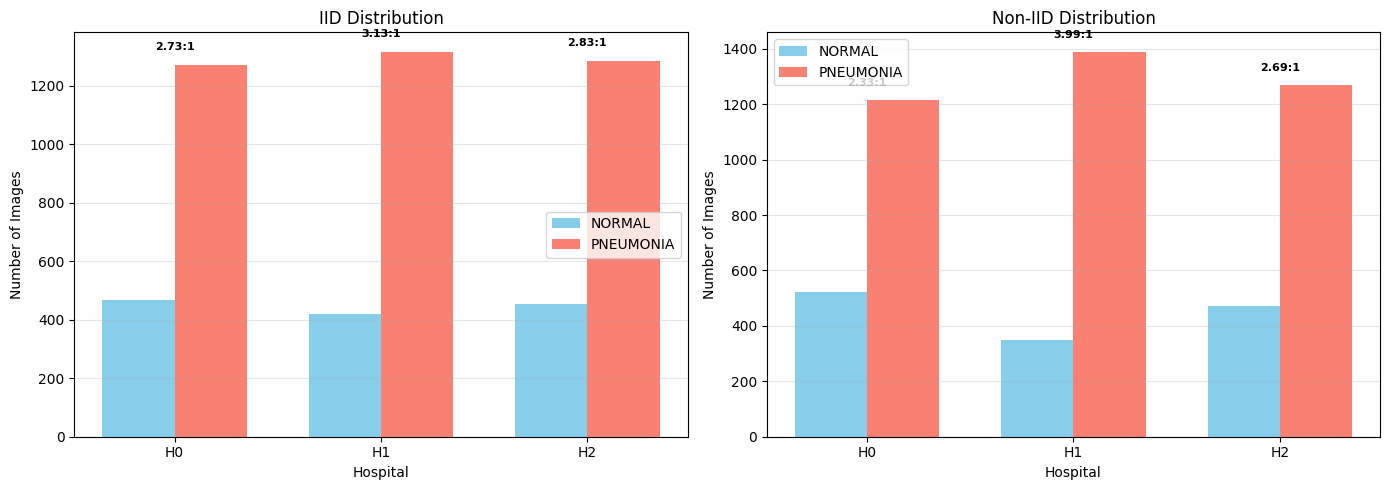

✅ Visualization complete!


In [ ]:
# ============================================
# CELL 9: Visualize Distributions
# ============================================
def visualize_partitions(iid_parts, non_iid_parts):
    """
    Visualize class distributions across hospitals
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    strategies = [
        ('IID', iid_parts),
        ('Non-IID', non_iid_parts)
    ]

    for ax_idx, (strategy_name, partitions) in enumerate(strategies):
        hospital_ids = [f"H{p['hospital_id']}" for p in partitions]
        normal_counts = [p['labels'].count(0) for p in partitions]
        pneumonia_counts = [p['labels'].count(1) for p in partitions]

        x = np.arange(len(hospital_ids))
        width = 0.35

        ax = axes[ax_idx]
        ax.bar(x - width/2, normal_counts, width, label='NORMAL', color='skyblue')
        ax.bar(x + width/2, pneumonia_counts, width, label='PNEUMONIA', color='salmon')

        ax.set_xlabel('Hospital')
        ax.set_ylabel('Number of Images')
        ax.set_title(f'{strategy_name} Distribution')
        ax.set_xticks(x)
        ax.set_xticklabels(hospital_ids)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

        # Add ratio labels
        for i, (n, p) in enumerate(zip(normal_counts, pneumonia_counts)):
            ratio = p / max(n, 1)
            ax.text(i, max(n, p) + 50, f"{ratio:.2f}:1",
                   ha='center', fontsize=8, fontweight='bold')

    plt.tight_layout()
    wandb.log({"partition_distributions": wandb.Image(fig)})
    plt.show()

visualize_partitions(iid_partitions, non_iid_partitions)
print("✅ Visualization complete!")

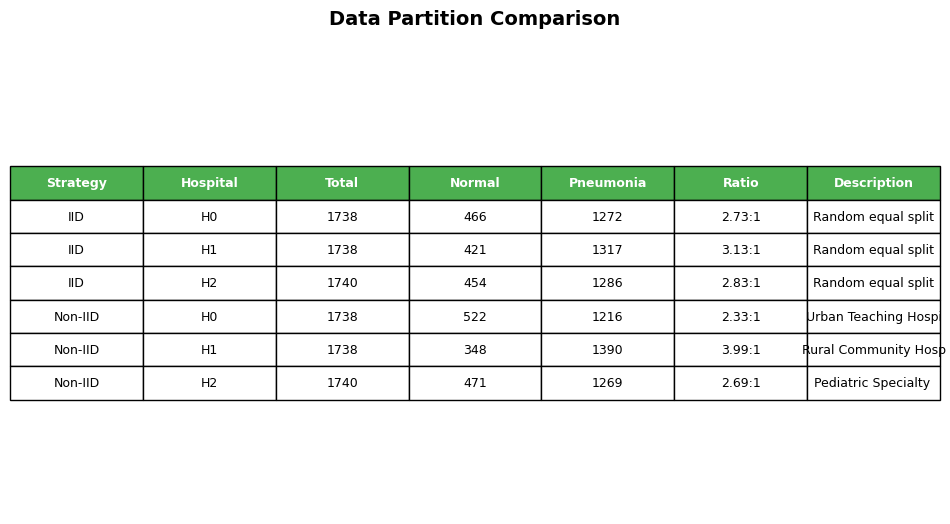

✅ Comparison table created!


In [ ]:
# ============================================
# CELL 10: Create Comparison Table
# ============================================
def create_comparison_table(iid_parts, non_iid_parts):
    """
    Create detailed comparison table
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('tight')
    ax.axis('off')

    # Prepare table data
    table_data = [
        ['Strategy', 'Hospital', 'Total', 'Normal', 'Pneumonia', 'Ratio', 'Description']
    ]

    # IID data
    for p in iid_parts:
        normal = p['labels'].count(0)
        pneumonia = p['labels'].count(1)
        ratio = f"{pneumonia / max(normal, 1):.2f}:1"
        table_data.append([
            'IID',
            f"H{p['hospital_id']}",
            len(p['labels']),
            normal,
            pneumonia,
            ratio,
            'Random equal split'
        ])

    # Non-IID data
    for p in non_iid_parts:
        normal = p['labels'].count(0)
        pneumonia = p['labels'].count(1)
        ratio = f"{pneumonia / max(normal, 1):.2f}:1"
        scenario = p.get('scenario', {})
        desc = scenario.get('name', 'Unknown')[:20]  # Truncate
        table_data.append([
            'Non-IID',
            f"H{p['hospital_id']}",
            len(p['labels']),
            normal,
            pneumonia,
            ratio,
            desc
        ])

    table = ax.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)

    # Style header row
    for i in range(7):
        table[(0, i)].set_facecolor('#4CAF50')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.title('Data Partition Comparison', fontsize=14, fontweight='bold', pad=20)
    wandb.log({"partition_comparison_table": wandb.Image(fig)})
    plt.show()

create_comparison_table(iid_partitions, non_iid_partitions)
print("✅ Comparison table created!")

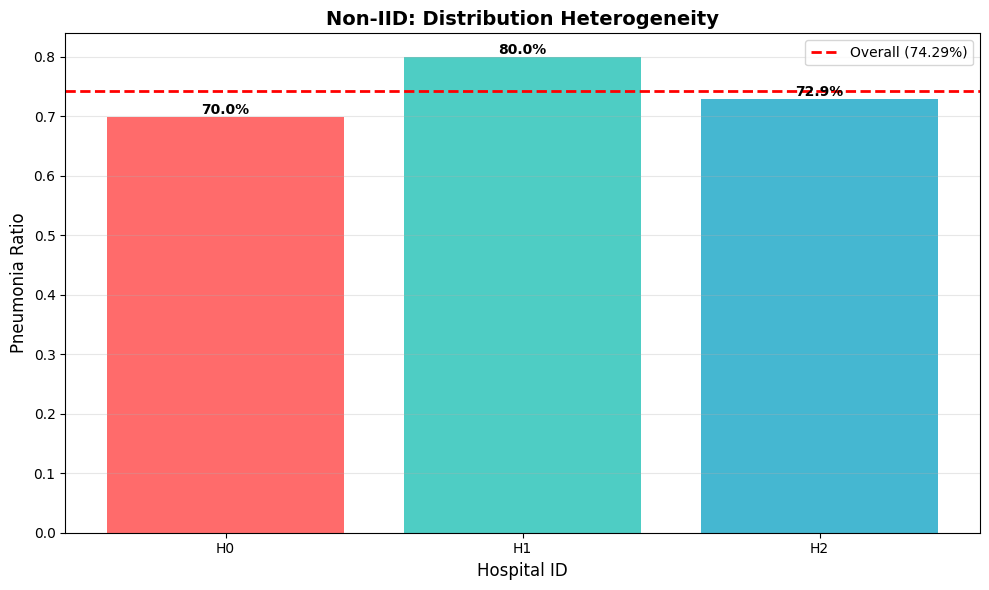

✅ Divergence plot created!


In [ ]:
# ============================================
# CELL 11: Visualize Distribution Divergence
# ============================================
def plot_distribution_divergence(non_iid_parts):
    """
    Show how far each hospital deviates from overall distribution
    """
    # Overall distribution
    all_labels = []
    for p in non_iid_parts:
        all_labels.extend(p['labels'])

    overall_pneumonia_ratio = all_labels.count(1) / len(all_labels)

    # Hospital ratios
    hospital_ratios = []
    for p in non_iid_parts:
        pneumonia_count = p['labels'].count(1)
        total = len(p['labels'])
        hospital_ratios.append(pneumonia_count / total)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(hospital_ratios))
    bars = ax.bar(x, hospital_ratios, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.axhline(y=overall_pneumonia_ratio, color='red', linestyle='--',
               linewidth=2, label=f'Overall ({overall_pneumonia_ratio:.2%})')

    ax.set_xlabel('Hospital ID', fontsize=12)
    ax.set_ylabel('Pneumonia Ratio', fontsize=12)
    ax.set_title('Non-IID: Distribution Heterogeneity', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"H{i}" for i in range(len(hospital_ratios))])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, (bar, ratio) in enumerate(zip(bars, hospital_ratios)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{ratio:.1%}',
                ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    wandb.log({"distribution_divergence": wandb.Image(fig)})
    plt.show()

plot_distribution_divergence(non_iid_partitions)
print("✅ Divergence plot created!")

In [ ]:
# ============================================
# CELL 12: Save Partition Metadata
# ============================================
def save_partition_metadata(iid_parts, non_iid_parts, save_dir):
    """
    Save detailed metadata about partitions
    """
    metadata = {
        "creation_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "num_hospitals": PARTITION_CONFIG["num_hospitals"],
        "total_training_images": len(train_images),

        "iid": {
            f"hospital_{p['hospital_id']}": {
                "total": len(p['labels']),
                "normal": p['labels'].count(0),
                "pneumonia": p['labels'].count(1),
                "ratio": p['labels'].count(1) / max(p['labels'].count(0), 1),
                "path": f"data/splits/iid/hospital_{p['hospital_id']}"
            }
            for p in iid_parts
        },

        "non_iid": {
            f"hospital_{p['hospital_id']}": {
                "total": len(p['labels']),
                "normal": p['labels'].count(0),
                "pneumonia": p['labels'].count(1),
                "ratio": p['labels'].count(1) / max(p['labels'].count(0), 1),
                "scenario": p.get('scenario', {}),
                "path": f"data/splits/non_iid/hospital_{p['hospital_id']}"
            }
            for p in non_iid_parts
        }
    }

    # Save to JSON
    metadata_path = os.path.join(save_dir, 'partition_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f"✅ Metadata saved to: {metadata_path}")
    return metadata

partition_metadata = save_partition_metadata(
    iid_partitions,
    non_iid_partitions,
    DATA_SPLITS
)

✅ Metadata saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/data/splits/partition_metadata.json


In [ ]:
# ============================================
# CELL 13: Verify Partitions
# ============================================
def verify_partitions(splits_dir):
    """
    Verify that all files were copied correctly
    """
    print("\n🔍 Verifying partitions...")

    for strategy in ['iid', 'non_iid']:
        strategy_dir = os.path.join(splits_dir, strategy)
        print(f"\n{strategy.upper()}:")

        for hospital_id in range(PARTITION_CONFIG["num_hospitals"]):
            hospital_dir = os.path.join(strategy_dir, f'hospital_{hospital_id}')

            normal_dir = os.path.join(hospital_dir, 'NORMAL')
            pneumonia_dir = os.path.join(hospital_dir, 'PNEUMONIA')

            normal_count = len([f for f in os.listdir(normal_dir)
                              if f.endswith(('.jpg', '.jpeg', '.png'))])
            pneumonia_count = len([f for f in os.listdir(pneumonia_dir)
                                  if f.endswith(('.jpg', '.jpeg', '.png'))])

            total = normal_count + pneumonia_count

            print(f"  Hospital {hospital_id}: {total} images "
                  f"(N:{normal_count}, P:{pneumonia_count})")

            assert total > 0, f"No images found in hospital_{hospital_id}!"

    print("\n✅ All partitions verified successfully!")

verify_partitions(DATA_SPLITS)


🔍 Verifying partitions...

IID:
  Hospital 0: 1738 images (N:466, P:1272)
  Hospital 1: 1738 images (N:421, P:1317)
  Hospital 2: 1740 images (N:454, P:1286)

NON_IID:
  Hospital 0: 1738 images (N:522, P:1216)
  Hospital 1: 1738 images (N:348, P:1390)
  Hospital 2: 1740 images (N:471, P:1269)

✅ All partitions verified successfully!


In [ ]:
# ============================================
# CELL 14: Summary
# ============================================
summary = {
    "date": datetime.now().strftime("%Y-%m-%d"),
    "week": 1,
    "day": 4,
    "milestone": "Data Partitioning Complete",
    "config": PARTITION_CONFIG,
    "partitions": partition_metadata,
    "folder_structure": {
        "iid": f"{DATA_SPLITS}/iid/hospital_0,1,2/NORMAL,PNEUMONIA/",
        "non_iid": f"{DATA_SPLITS}/non_iid/hospital_0,1,2/NORMAL,PNEUMONIA/"
    },
    "next_steps": [
        "Day 5: Train centralized baseline model",
        "Week 2: Implement Flower federated learning"
    ]
}

summary_path = os.path.join(RESULTS_DIR, 'day4_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

# Log to WandB
summary_table = wandb.Table(
    columns=["Metric", "Value"],
    data=[
        ["Total Training Images", str(len(train_images))],
        ["Number of Hospitals", str(PARTITION_CONFIG["num_hospitals"])],
        ["Partition Strategies", "IID + Non-IID"],
        ["IID Balance", "~Equal distribution"],
        ["Non-IID Variance", "High heterogeneity"],
        ["Status", "✅ Complete"]
    ]
)
wandb.log({"day4_summary": summary_table})

print("\n" + "="*60)
print("🎉 DAY 4 COMPLETE!")
print("="*60)
print(f"\n📊 Partitions Created:")
print(f"   Strategy 1: IID (equal random splits)")
print(f"   Strategy 2: Non-IID (heterogeneous)")
print(f"   Hospitals: {PARTITION_CONFIG['num_hospitals']}")
print(f"\n📁 Saved to: {DATA_SPLITS}")
print(f"   ├── iid/hospital_0,1,2/")
print(f"   └── non_iid/hospital_0,1,2/")
print(f"\n✅ Next: Day 5 - Centralized Baseline Training")
print("="*60)

wandb.finish()


🎉 DAY 4 COMPLETE!

📊 Partitions Created:
   Strategy 1: IID (equal random splits)
   Strategy 2: Non-IID (heterogeneous)
   Hospitals: 3

📁 Saved to: /content/drive/MyDrive/FL-Pneumonia-Detection/data/splits
   ├── iid/hospital_0,1,2/
   └── non_iid/hospital_0,1,2/

✅ Next: Day 5 - Centralized Baseline Training
